In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
generation_data = pd.read_csv('Generation_Data3.csv')
weather_data = pd.read_csv('Weather_Data3.csv')

In [3]:
generation_data.info()
generation_data.describe()
generation_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93756 entries, 0 to 93755
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   DATE_TIME  93756 non-null  object 
 1   AC_POWER   93756 non-null  float64
 2   DC_POWER   93756 non-null  float64
dtypes: float64(2), object(1)
memory usage: 2.1+ MB


,DATE_TIME,AC_POWER,DC_POWER
0,01-01-2020 06:15,0.04165,0.041650
1,01-01-2020 06:30,0.35867,0.364767
2,01-01-2020 06:45,1.77553,1.825467
3,01-01-2020 07:00,3.40627,3.506753
4,01-01-2020 07:15,6.78082,6.969747


In [4]:
weather_data.info()
weather_data.describe()
weather_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175389 entries, 0 to 175388
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   DATE_TIME    175389 non-null  object 
 1   TEMPERATURE  175389 non-null  float64
 2   HUMIDITY     175389 non-null  float64
 3   IRRADIATION  175389 non-null  float64
dtypes: float64(3), object(1)
memory usage: 5.4+ MB


,DATE_TIME,TEMPERATURE,HUMIDITY,IRRADIATION
0,01-01-2020 00:00,20.310,15.1900,0.0
1,01-01-2020 00:15,20.295,15.1825,0.0
2,01-01-2020 00:30,20.280,15.1750,0.0
3,01-01-2020 00:45,20.265,15.1675,0.0
4,01-01-2020 01:00,20.250,15.1600,0.0


In [5]:
df_solar = pd.merge(generation_data,weather_data,on='DATE_TIME')
df_solar.info()
df_solar.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93756 entries, 0 to 93755
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    93756 non-null  object 
 1   AC_POWER     93756 non-null  float64
 2   DC_POWER     93756 non-null  float64
 3   TEMPERATURE  93756 non-null  float64
 4   HUMIDITY     93756 non-null  float64
 5   IRRADIATION  93756 non-null  float64
dtypes: float64(5), object(1)
memory usage: 4.3+ MB


,DATE_TIME,AC_POWER,DC_POWER,TEMPERATURE,HUMIDITY,IRRADIATION
0,01-01-2020 06:15,0.04165,0.041650,21.4225,15.7650,65.9425
1,01-01-2020 06:30,0.35867,0.364767,21.8850,16.0000,100.9850
2,01-01-2020 06:45,1.77553,1.825467,22.3475,16.2350,136.0275
3,01-01-2020 07:00,3.40627,3.506753,22.8100,16.4700,171.0700
4,01-01-2020 07:15,6.78082,6.969747,23.2275,16.5825,211.0950


Correlation between AC_POWER and DC_POWER = 1.00


<Axes: xlabel='AC_POWER', ylabel='DC_POWER'>

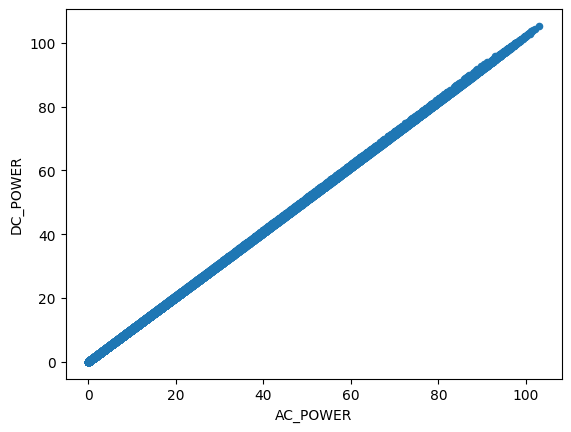

In [6]:
c = df_solar['AC_POWER'].corr(df_solar["DC_POWER"])
print("Correlation between AC_POWER and DC_POWER = {:.2f}".format(c))
df_solar.plot.scatter(x="AC_POWER", y="DC_POWER")

In [7]:
df_solar = df_solar.drop(columns=["DC_POWER"])
df_solar.head()

,DATE_TIME,AC_POWER,TEMPERATURE,HUMIDITY,IRRADIATION
0,01-01-2020 06:15,0.04165,21.4225,15.7650,65.9425
1,01-01-2020 06:30,0.35867,21.8850,16.0000,100.9850
2,01-01-2020 06:45,1.77553,22.3475,16.2350,136.0275
3,01-01-2020 07:00,3.40627,22.8100,16.4700,171.0700
4,01-01-2020 07:15,6.78082,23.2275,16.5825,211.0950


In [8]:
# Specify the correct format and set dayfirst to True
df_solar["TIME"] = pd.to_datetime(df_solar["DATE_TIME"], format='%d-%m-%Y %H:%M', dayfirst=True).dt.time
# add hours and minutes for ml models
df_solar['HOURS'] = pd.to_datetime(df_solar['TIME'],format='%H:%M:%S').dt.hour
df_solar['MINUTES'] = pd.to_datetime(df_solar['TIME'],format='%H:%M:%S').dt.minute
df_solar['TOTAL_MINUTES_PASS'] = df_solar['MINUTES'] + df_solar['HOURS']*60

df_solar = df_solar.drop(columns=['HOURS', 'MINUTES', 'TIME', 'DATE_TIME'], axis=1)

In [9]:
df_solar.info()
df_solar.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93756 entries, 0 to 93755
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   AC_POWER            93756 non-null  float64
 1   TEMPERATURE         93756 non-null  float64
 2   HUMIDITY            93756 non-null  float64
 3   IRRADIATION         93756 non-null  float64
 4   TOTAL_MINUTES_PASS  93756 non-null  int32  
dtypes: float64(4), int32(1)
memory usage: 3.2 MB


,AC_POWER,TEMPERATURE,HUMIDITY,IRRADIATION,TOTAL_MINUTES_PASS
0,0.04165,21.4225,15.7650,65.9425,375
1,0.35867,21.8850,16.0000,100.9850,390
2,1.77553,22.3475,16.2350,136.0275,405
3,3.40627,22.8100,16.4700,171.0700,420
4,6.78082,23.2275,16.5825,211.0950,435


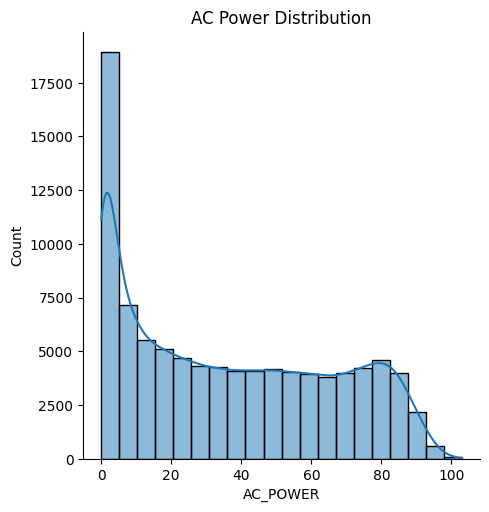

In [10]:
sns.displot(df_solar['AC_POWER'], kde=True, bins = 20).set(title = "AC Power Distribution")
plt.show()

In [11]:
import pandas as pd

# Assuming df_solar is already defined and loaded
skewness_ac_power = df_solar['AC_POWER'].skew()

print(f"Skewness value for AC_POWER: {skewness_ac_power}")

Skewness value for AC_POWER: 0.3205565325959112


In [12]:
# Check for zero values in the AC_POWER column
ac_power_zeros = df_solar[df_solar['AC_POWER'] == 0]
print(f"Number of zero values in AC_POWER: {len(ac_power_zeros)}")

# Check for zero values in the IRRADIATION column
irradiation_zeros = df_solar[df_solar['IRRADIATION'] == 0]
print(f"Number of zero values in IRRADIATION: {len(irradiation_zeros)}")

Number of zero values in AC_POWER: 4240
Number of zero values in IRRADIATION: 12909


In [13]:
# Remove rows where AC_POWER or IRRADIATION is zero
df_solar = df_solar[(df_solar['AC_POWER'] != 0) & (df_solar['IRRADIATION'] != 0)]

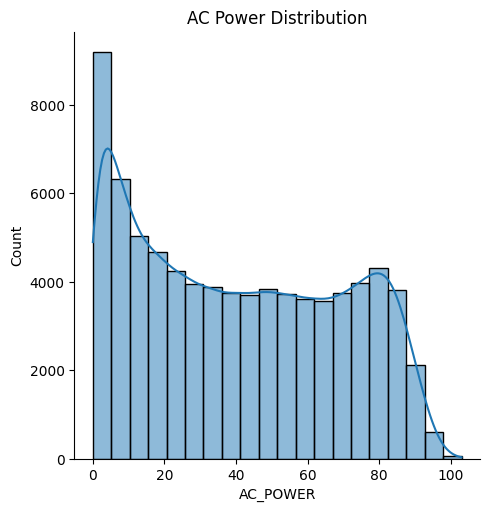

In [14]:
sns.displot(df_solar['AC_POWER'], kde=True, bins = 20).set(title = "AC Power Distribution")
plt.show()

In [15]:
import pandas as pd

# Assuming df_solar is already defined and loaded
skewness_ac_power = df_solar['AC_POWER'].skew()

print(f"Skewness value for AC_POWER: {skewness_ac_power}")

Skewness value for AC_POWER: 0.18813016984281242


                    AC_POWER  TEMPERATURE  HUMIDITY  IRRADIATION  \
AC_POWER            1.000000     0.565402 -0.407076     0.829294   
TEMPERATURE         0.565402     1.000000 -0.466591     0.536933   
HUMIDITY           -0.407076    -0.466591  1.000000    -0.395483   
IRRADIATION         0.829294     0.536933 -0.395483     1.000000   
TOTAL_MINUTES_PASS  0.125746     0.260641 -0.062626    -0.250500   

                    TOTAL_MINUTES_PASS  
AC_POWER                      0.125746  
TEMPERATURE                   0.260641  
HUMIDITY                     -0.062626  
IRRADIATION                  -0.250500  
TOTAL_MINUTES_PASS            1.000000  


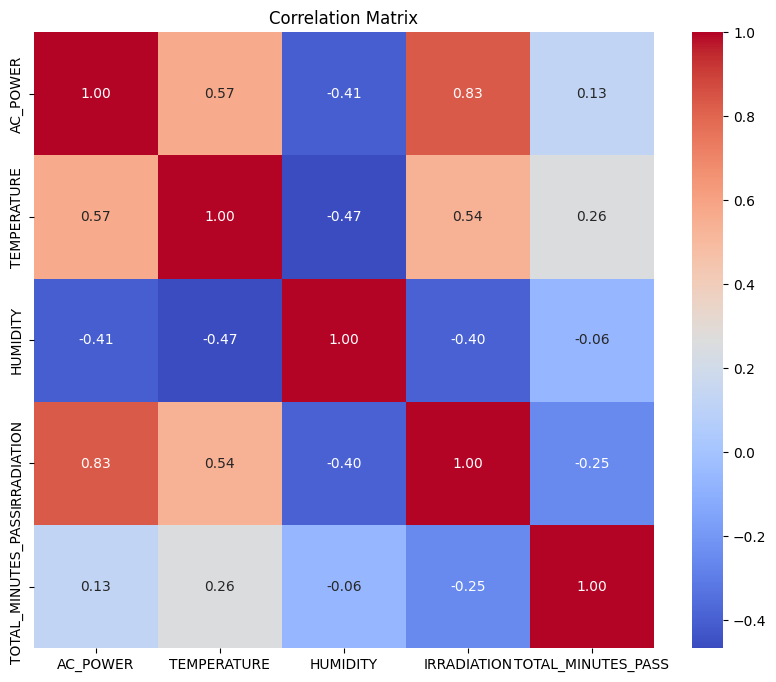

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df_solar = df_solar.select_dtypes(include=[np.number])

# Calculate the correlation matrix
correlation_matrix = numeric_df_solar.corr()

# Print the correlation matrix
print(correlation_matrix)

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [17]:
import pandas as pd

# Assuming df_solar is already defined and loaded
skewness_ac_power = df_solar['AC_POWER'].skew()
skewness_temperature = df_solar['TEMPERATURE'].skew()
skewness_humidity = df_solar['HUMIDITY'].skew()
skewness_irradiation = df_solar['IRRADIATION'].skew()

print(f"Skewness value for AC_POWER: {skewness_ac_power}")
print(f"Skewness value for temperature: {skewness_temperature}")
print(f"Skewness value for Humidity: {skewness_humidity}")
print(f"Skewness value for Irradiation: {skewness_irradiation}")

Skewness value for AC_POWER: 0.18813016984281242
Skewness value for temperature: 0.34705583221655123
Skewness value for Humidity: -0.6175988783405666
Skewness value for Irradiation: 0.14319760816489221


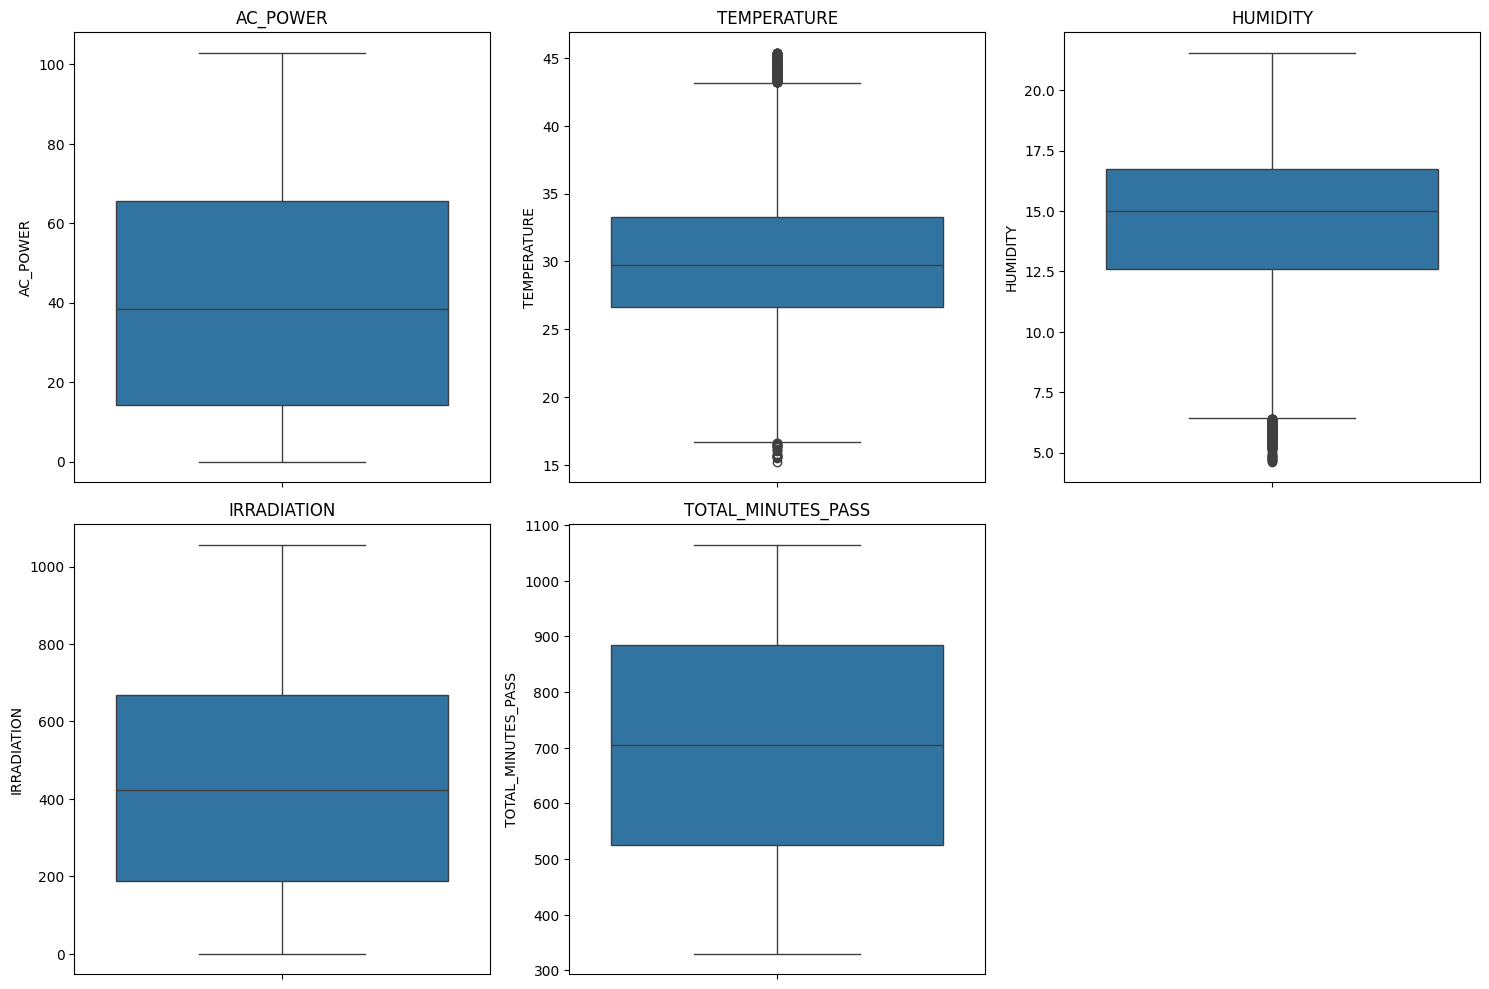

Count of outliers identified using the IQR method:
AC_POWER: 0
TEMPERATURE: 210
HUMIDITY: 209
IRRADIATION: 0
TOTAL_MINUTES_PASS: 0
Outliers identified using the IQR method:
       AC_POWER  TEMPERATURE  HUMIDITY  IRRADIATION TOTAL_MINUTES_PASS
19234   0.09292      15.4975   10.3575      92.1875                375
19235   0.48414      16.1050   10.4750     138.1250                390
37648   0.07011      16.2000   11.1150      93.6400                375
37744   0.01477      16.3600   11.0725      82.0275                375
37792   0.05358      15.6575   11.0250      75.1625                375
...         ...          ...       ...          ...                ...
81592  70.64944      41.1625    6.3075     933.7525                585
81593  73.15756      41.7300    6.2600     963.9200                600
81594  76.35851      42.1000    6.2525     981.5025                615
81595  79.09648      42.4700    6.2450     999.0850                630
81596  80.63478      42.8400    6.2375    1016

C:\Users\netha\AppData\Local\Temp\ipykernel_12976\3944220172.py:51: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  outliers = pd.concat([outliers, outliers_in_column])


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_solar is your DataFrame
# Plot box plots for each numeric column
numeric_columns = df_solar.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(15, 10))
for i, column in enumerate(numeric_columns, 1):
    plt.subplot(len(numeric_columns) // 3 + 1, 3, i)
    sns.boxplot(y=df_solar[column])
    plt.title(column)

plt.tight_layout()
plt.show()


# Function to identify outliers using the IQR method and count them
def identify_outliers_iqr(df):
    outliers_count = {}
    for column in df.select_dtypes(include=[np.number]).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers_in_column = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
        outliers_count[column] = outliers_in_column.shape[0]
    return outliers_count

# Identify outliers in the DataFrame and count them
outliers_count = identify_outliers_iqr(df_solar)

# Print the count of outliers for each column
print("Count of outliers identified using the IQR method:")
for column, count in outliers_count.items():
    print(f"{column}: {count}")



# Function to identify outliers using the IQR method
def identify_outliers_iqr1(df):
    outliers = pd.DataFrame(columns=df.columns)
    for column in df.select_dtypes(include=[np.number]).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers_in_column = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
        outliers = pd.concat([outliers, outliers_in_column])
    return outliers.drop_duplicates()

# Identify outliers in the DataFrame
outliers = identify_outliers_iqr1(df_solar)

# Print the outliers
print("Outliers identified using the IQR method:")
print(outliers)




In [19]:
# Function to cap outliers using the IQR method
def cap_outliers_iqr(df):
    for column in df.select_dtypes(include=[np.number]).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Cap the values
        df[column] = df[column].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)
    return df

# Apply the function to cap outliers in the DataFrame
df_solar = cap_outliers_iqr(df_solar)

# Verify the changes
print("DataFrame after capping outliers:")
print(df_solar.describe())

DataFrame after capping outliers:
           AC_POWER   TEMPERATURE      HUMIDITY   IRRADIATION  \
count  78089.000000  78089.000000  78089.000000  78089.000000   
mean      40.632190     30.173443     14.472434    435.465873   
std       28.235407      4.762981      2.979477    277.784268   
min        0.000010     16.666250      6.418750      0.225000   
25%       14.271960     26.615000     12.610000    188.500000   
50%       38.533820     29.750000     15.020000    423.990000   
75%       65.662480     33.247500     16.737500    667.450000   
max      103.003050     43.196250     21.560000   1056.720000   

       TOTAL_MINUTES_PASS  
count        78089.000000  
mean           708.546722  
std            206.143867  
min            330.000000  
25%            525.000000  
50%            705.000000  
75%            885.000000  
max           1065.000000  


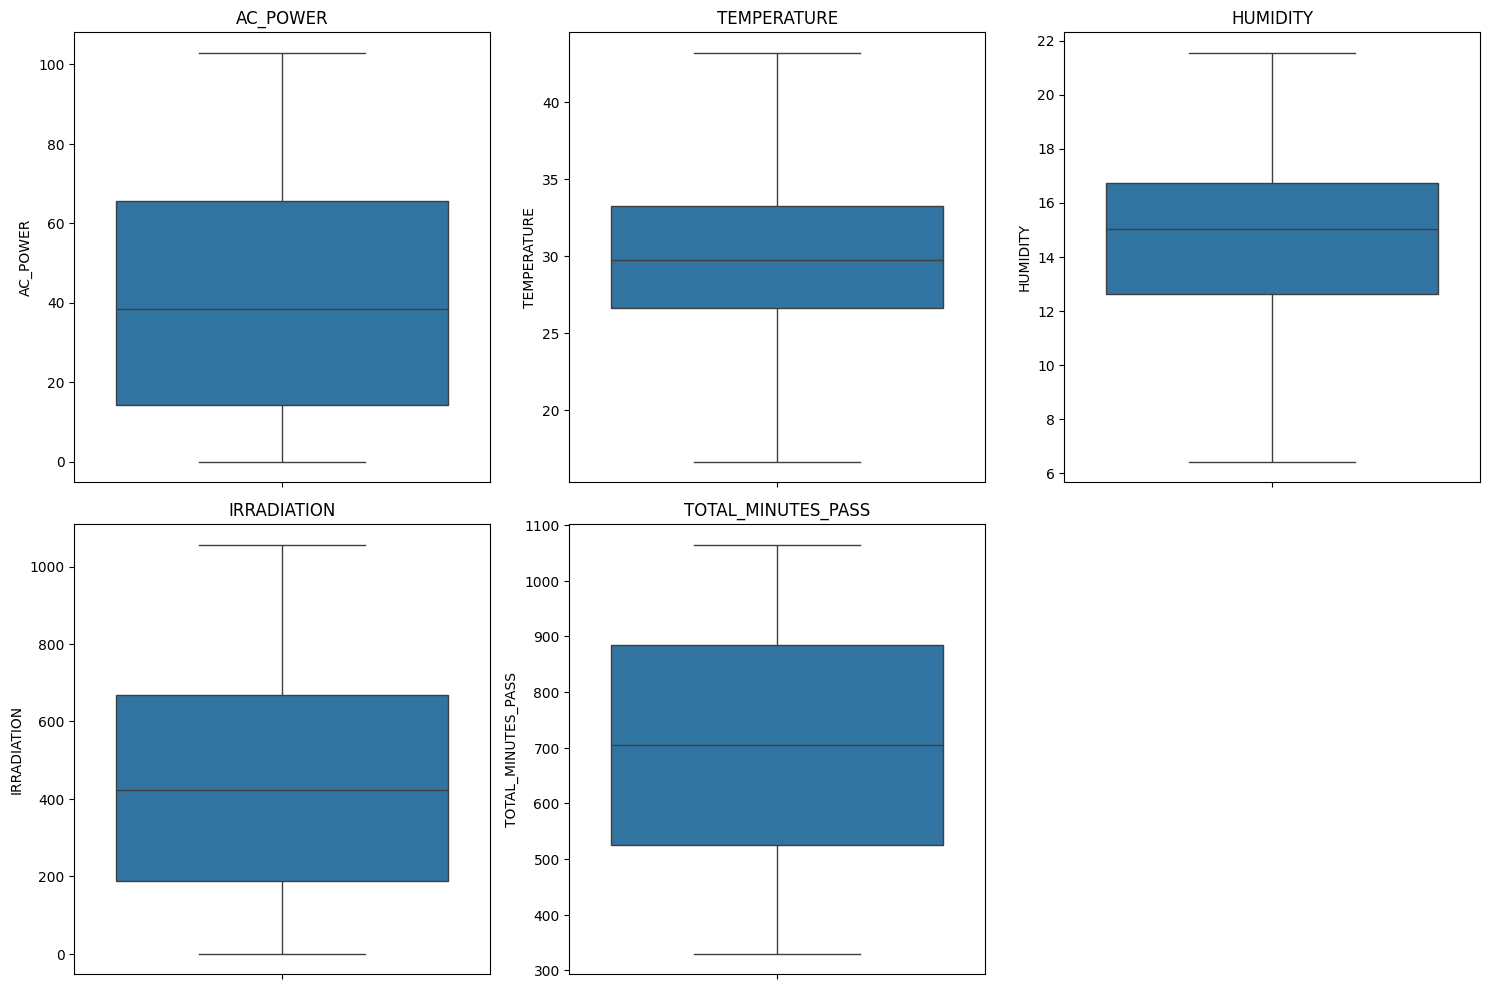

Outliers identified using the IQR method:
Empty DataFrame
Columns: [AC_POWER, TEMPERATURE, HUMIDITY, IRRADIATION, TOTAL_MINUTES_PASS]
Index: []
DataFrame after removing outliers:
       AC_POWER  TEMPERATURE  HUMIDITY  IRRADIATION  TOTAL_MINUTES_PASS
0       0.04165      21.4225   15.7650      65.9425                 375
1       0.35867      21.8850   16.0000     100.9850                 390
2       1.77553      22.3475   16.2350     136.0275                 405
3       3.40627      22.8100   16.4700     171.0700                 420
4       6.78082      23.2275   16.5825     211.0950                 435
...         ...          ...       ...          ...                 ...
86105  13.78557      29.1975   16.3875      95.8500                1005
86106   9.81416      28.8200   16.6000      58.6000                1020
86107   7.28979      28.4900   16.7375      43.9500                1035
86108   4.68736      28.1600   16.8750      29.3000                1050
86109   2.77357      27.8300 

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_solar is your DataFrame
# Plot box plots for each numeric column
numeric_columns = df_solar.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(15, 10))
for i, column in enumerate(numeric_columns, 1):
    plt.subplot(len(numeric_columns) // 3 + 1, 3, i)
    sns.boxplot(y=df_solar[column])
    plt.title(column)

plt.tight_layout()
plt.show()


# Function to identify outliers using the IQR method
def identify_outliers_iqr(df):
    outliers = pd.DataFrame(columns=df.columns)
    for column in df.select_dtypes(include=[np.number]).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers_in_column = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
        outliers = pd.concat([outliers, outliers_in_column])
    return outliers.drop_duplicates()

# Identify outliers in the DataFrame
outliers = identify_outliers_iqr(df_solar)

# Print the outliers
print("Outliers identified using the IQR method:")
print(outliers)


# Remove outliers from the DataFrame
df_solar = df_solar[~df_solar.index.isin(outliers.index)]

# Verify the changes
print("DataFrame after removing outliers:")
print(df_solar)

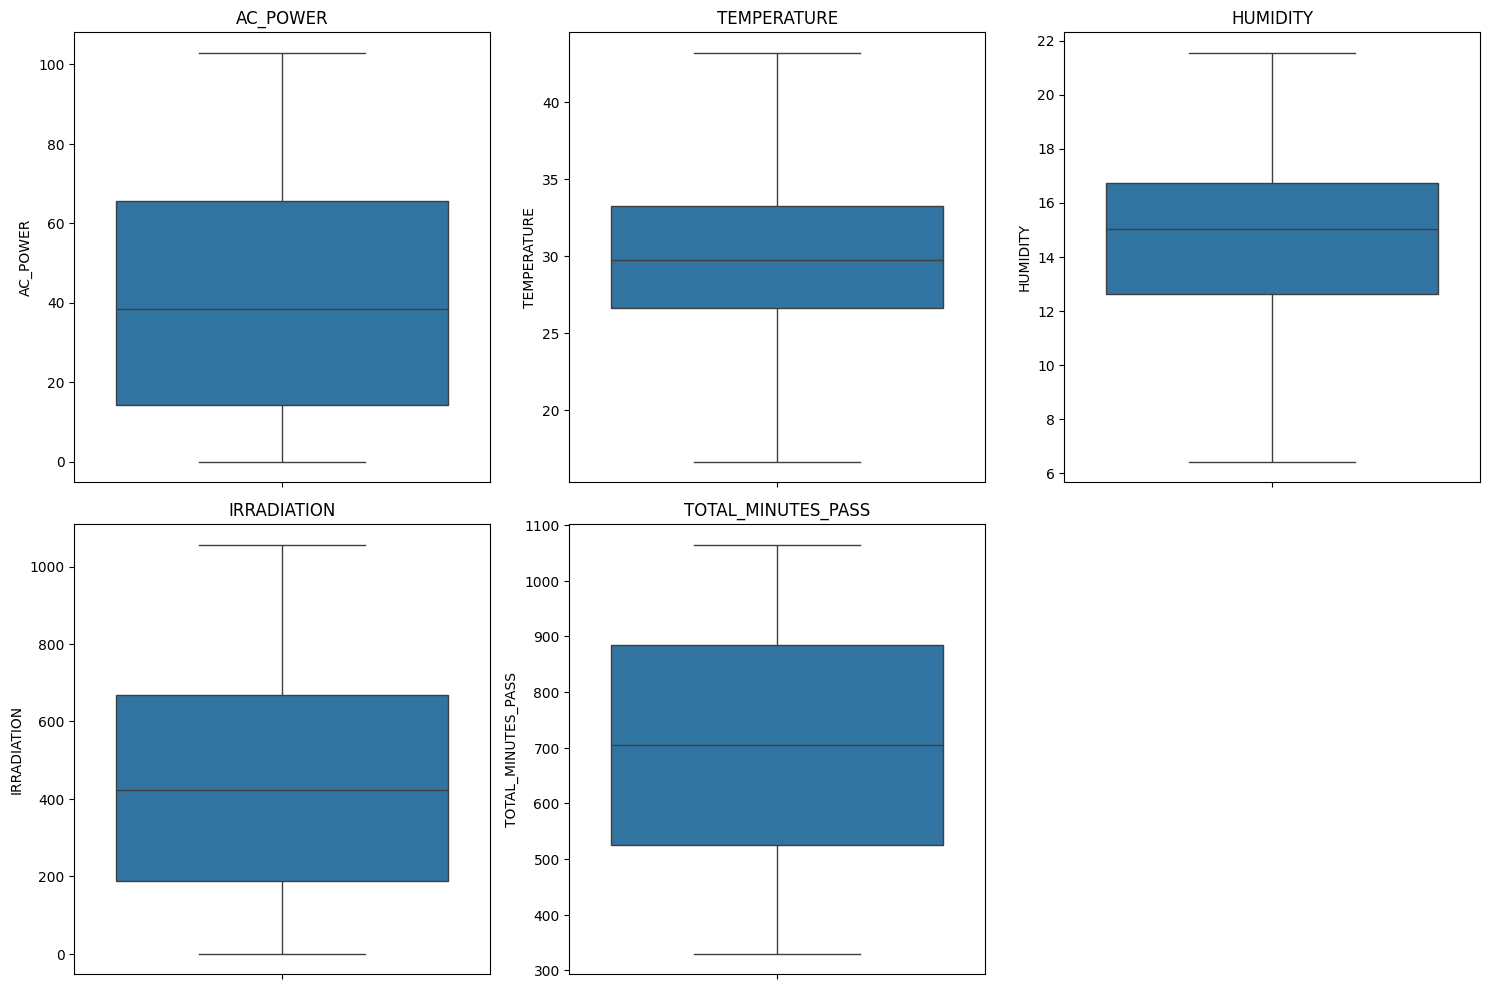

Outliers identified using the IQR method:
Empty DataFrame
Columns: [AC_POWER, TEMPERATURE, HUMIDITY, IRRADIATION, TOTAL_MINUTES_PASS]
Index: []
DataFrame after removing outliers:
       AC_POWER  TEMPERATURE  HUMIDITY  IRRADIATION  TOTAL_MINUTES_PASS
0       0.04165      21.4225   15.7650      65.9425                 375
1       0.35867      21.8850   16.0000     100.9850                 390
2       1.77553      22.3475   16.2350     136.0275                 405
3       3.40627      22.8100   16.4700     171.0700                 420
4       6.78082      23.2275   16.5825     211.0950                 435
...         ...          ...       ...          ...                 ...
86105  13.78557      29.1975   16.3875      95.8500                1005
86106   9.81416      28.8200   16.6000      58.6000                1020
86107   7.28979      28.4900   16.7375      43.9500                1035
86108   4.68736      28.1600   16.8750      29.3000                1050
86109   2.77357      27.8300 

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_solar is your DataFrame
# Plot box plots for each numeric column
numeric_columns = df_solar.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(15, 10))
for i, column in enumerate(numeric_columns, 1):
    plt.subplot(len(numeric_columns) // 3 + 1, 3, i)
    sns.boxplot(y=df_solar[column])
    plt.title(column)

plt.tight_layout()
plt.show()


# Function to identify outliers using the IQR method
def identify_outliers_iqr(df):
    outliers = pd.DataFrame(columns=df.columns)
    for column in df.select_dtypes(include=[np.number]).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers_in_column = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
        outliers = pd.concat([outliers, outliers_in_column])
    return outliers.drop_duplicates()

# Identify outliers in the DataFrame
outliers = identify_outliers_iqr(df_solar)

# Print the outliers
print("Outliers identified using the IQR method:")
print(outliers)


# Remove outliers from the DataFrame
df_solar = df_solar[~df_solar.index.isin(outliers.index)]

# Verify the changes
print("DataFrame after removing outliers:")
print(df_solar)

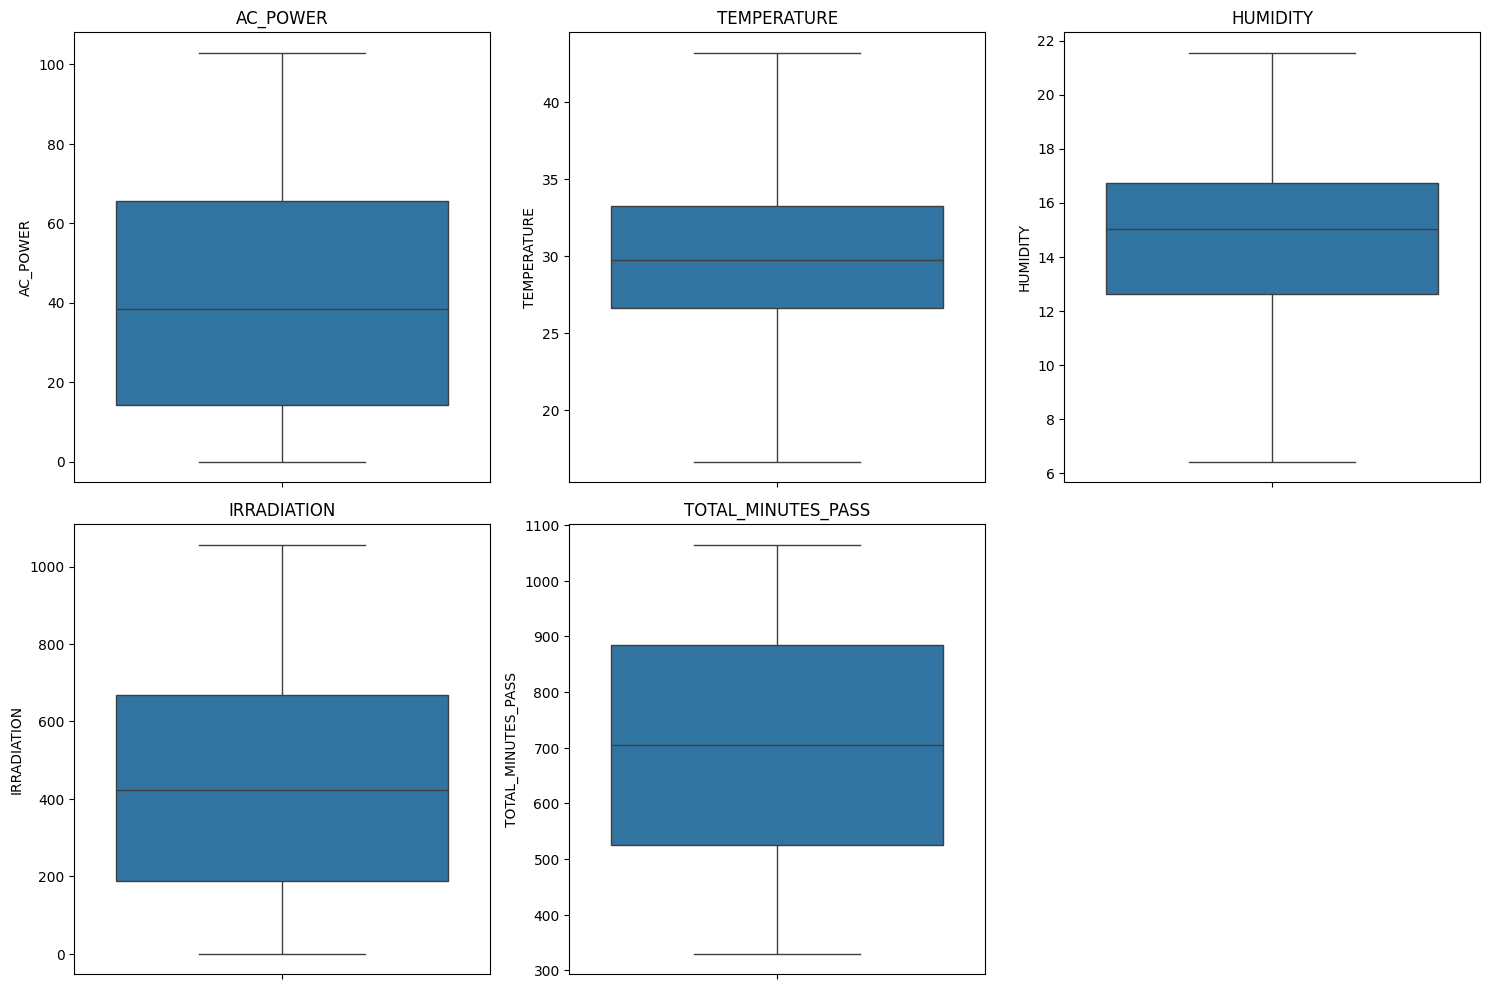

Outliers identified using the IQR method:
Empty DataFrame
Columns: [AC_POWER, TEMPERATURE, HUMIDITY, IRRADIATION, TOTAL_MINUTES_PASS]
Index: []


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_solar is your DataFrame
# Plot box plots for each numeric column
numeric_columns = df_solar.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(15, 10))
for i, column in enumerate(numeric_columns, 1):
    plt.subplot(len(numeric_columns) // 3 + 1, 3, i)
    sns.boxplot(y=df_solar[column])
    plt.title(column)

plt.tight_layout()
plt.show()


# Function to identify outliers using the IQR method
def identify_outliers_iqr(df):
    outliers = pd.DataFrame(columns=df.columns)
    for column in df.select_dtypes(include=[np.number]).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers_in_column = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
        outliers = pd.concat([outliers, outliers_in_column])
    return outliers.drop_duplicates()

# Identify outliers in the DataFrame
outliers = identify_outliers_iqr(df_solar)

# Print the outliers
print("Outliers identified using the IQR method:")
print(outliers)


In [23]:
import pandas as pd

# Assuming df_solar is already defined and loaded
skewness_ac_power = df_solar['AC_POWER'].skew()
skewness_temperature = df_solar['TEMPERATURE'].skew()
skewness_humidity = df_solar['HUMIDITY'].skew()
skewness_irradiation = df_solar['IRRADIATION'].skew()

print(f"Skewness value for AC_POWER: {skewness_ac_power}")
print(f"Skewness value for temperature: {skewness_temperature}")
print(f"Skewness value for Humidity: {skewness_humidity}")
print(f"Skewness value for Irradiation: {skewness_irradiation}")

Skewness value for AC_POWER: 0.18813016984281242
Skewness value for temperature: 0.33991906759185053
Skewness value for Humidity: -0.608897561925665
Skewness value for Irradiation: 0.14319760816489221


In [24]:
X = df_solar.drop(columns='AC_POWER', axis=1) #features
y = df_solar['AC_POWER']

X.sample(5)

,TEMPERATURE,HUMIDITY,IRRADIATION,TOTAL_MINUTES_PASS
25190,30.020,16.6100,401.9500,450
75741,26.325,14.1550,679.2850,630
29172,31.635,16.6875,719.5375,735
46003,35.430,13.9975,531.0325,855
61956,38.790,7.6450,872.8500,570


In [25]:
X.describe()

,TEMPERATURE,HUMIDITY,IRRADIATION,TOTAL_MINUTES_PASS
count,78089.000000,78089.000000,78089.000000,78089.000000
mean,30.173443,14.472434,435.465873,708.546722
std,4.762981,2.979477,277.784268,206.143867
min,16.666250,6.418750,0.225000,330.000000
25%,26.615000,12.610000,188.500000,525.000000
50%,29.750000,15.020000,423.990000,705.000000
75%,33.247500,16.737500,667.450000,885.000000
max,43.196250,21.560000,1056.720000,1065.000000


In [26]:
y.info()
y.head(5)

<class 'pandas.core.series.Series'>
Index: 78089 entries, 0 to 86109
Series name: AC_POWER
Non-Null Count  Dtype  
--------------  -----  
78089 non-null  float64
dtypes: float64(1)
memory usage: 1.2 MB


0    0.04165
1    0.35867
2    1.77553
3    3.40627
4    6.78082
Name: AC_POWER, dtype: float64

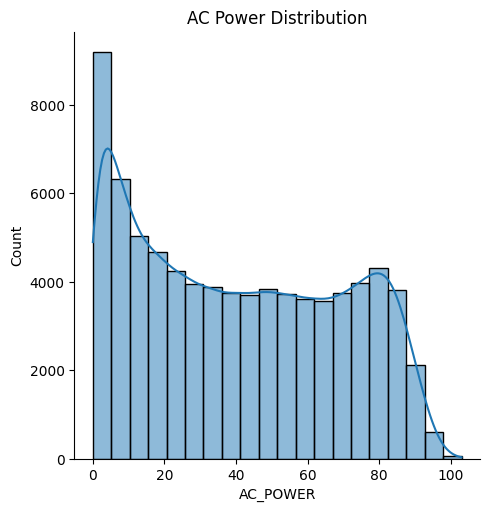

In [27]:
sns.displot(y, kde=True, bins = 20).set(title = "AC Power Distribution")
plt.show()

In [28]:
# Train test split
from sklearn.model_selection import train_test_split
X_valtrain, X_test, y_valtrain, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
X_valtrain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 62471 entries, 46479 to 17291
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   TEMPERATURE         62471 non-null  float64
 1   HUMIDITY            62471 non-null  float64
 2   IRRADIATION         62471 non-null  float64
 3   TOTAL_MINUTES_PASS  62471 non-null  int64  
dtypes: float64(3), int64(1)
memory usage: 2.4 MB


In [30]:
X_valtrain.isnull().sum() #Check for the number of null values -> no null values found

TEMPERATURE           0
HUMIDITY              0
IRRADIATION           0
TOTAL_MINUTES_PASS    0
dtype: int64

In [31]:
X_test.isnull().sum()

TEMPERATURE           0
HUMIDITY              0
IRRADIATION           0
TOTAL_MINUTES_PASS    0
dtype: int64

In [32]:
y_valtrain.isnull().sum()

np.int64(0)

In [33]:
y_test.isnull().sum()

np.int64(0)

Text(0.5, 1.0, 'AC Power vs. Irradiation')

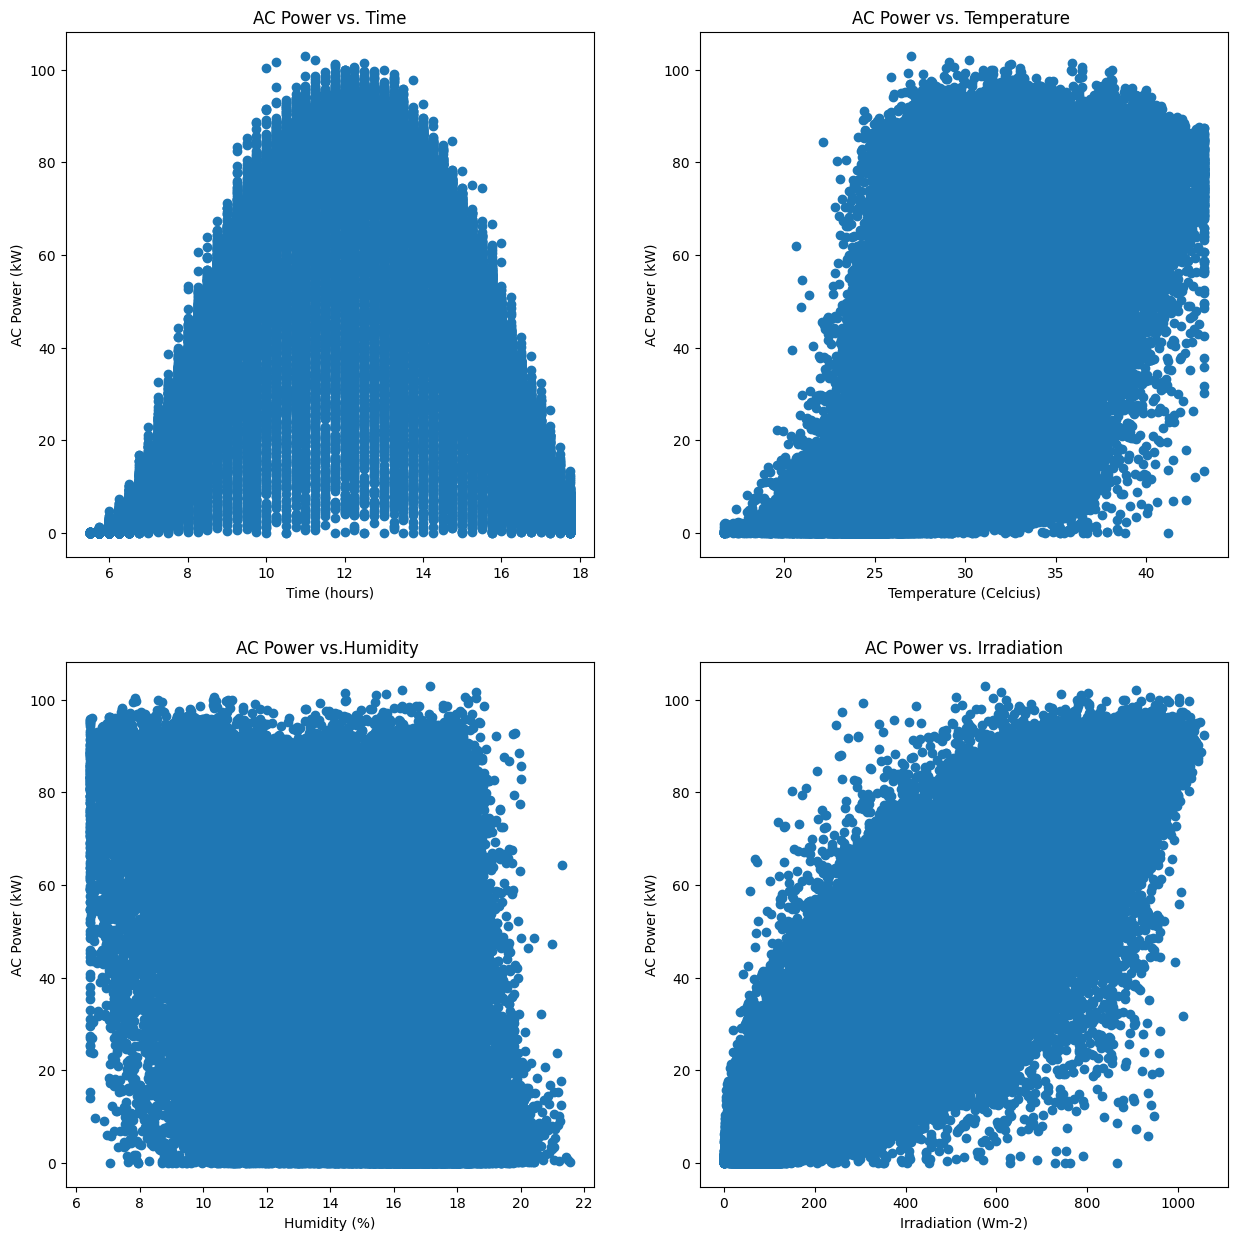

In [34]:
#Plots for AC power against input features
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 15))

axes[0,0].scatter(X_valtrain.TOTAL_MINUTES_PASS/60, y_valtrain)
axes[0,0].set_xlabel('Time (hours)')
axes[0,0].set_ylabel('AC Power (kW)')
axes[0,0].set_title('AC Power vs. Time')

axes[0,1].scatter(X_valtrain.TEMPERATURE, y_valtrain)
axes[0,1].set_xlabel('Temperature (Celcius)')
axes[0,1].set_ylabel('AC Power (kW)')
axes[0,1].set_title('AC Power vs. Temperature ')

axes[1,0].scatter(X_valtrain.HUMIDITY, y_valtrain)
axes[1,0].set_xlabel('Humidity (%)')
axes[1,0].set_ylabel('AC Power (kW)')
axes[1,0].set_title('AC Power vs.Humidity ')

axes[1,1].scatter(X_valtrain.IRRADIATION, y_valtrain)
axes[1,1].set_xlabel('Irradiation (Wm-2)')
axes[1,1].set_ylabel('AC Power (kW)')
axes[1,1].set_title('AC Power vs. Irradiation')

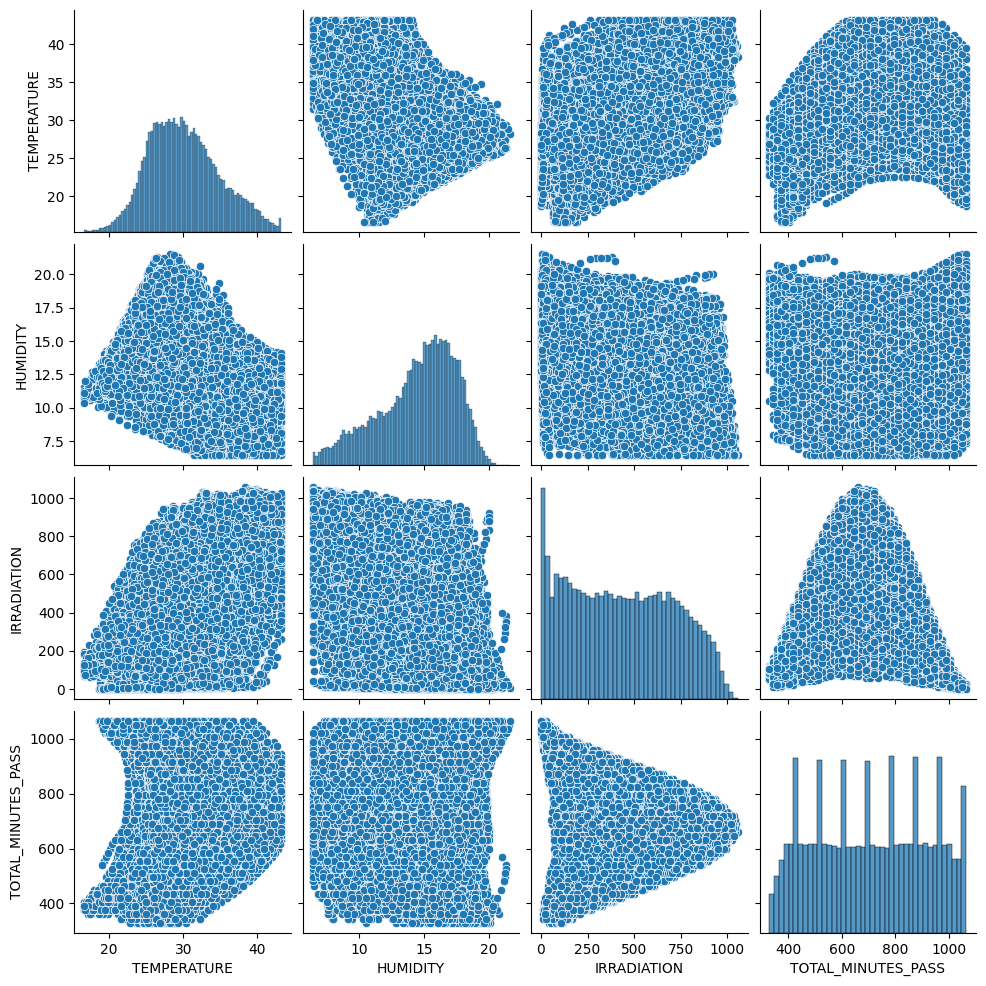

In [35]:
sns.pairplot(X_valtrain) # pair plot

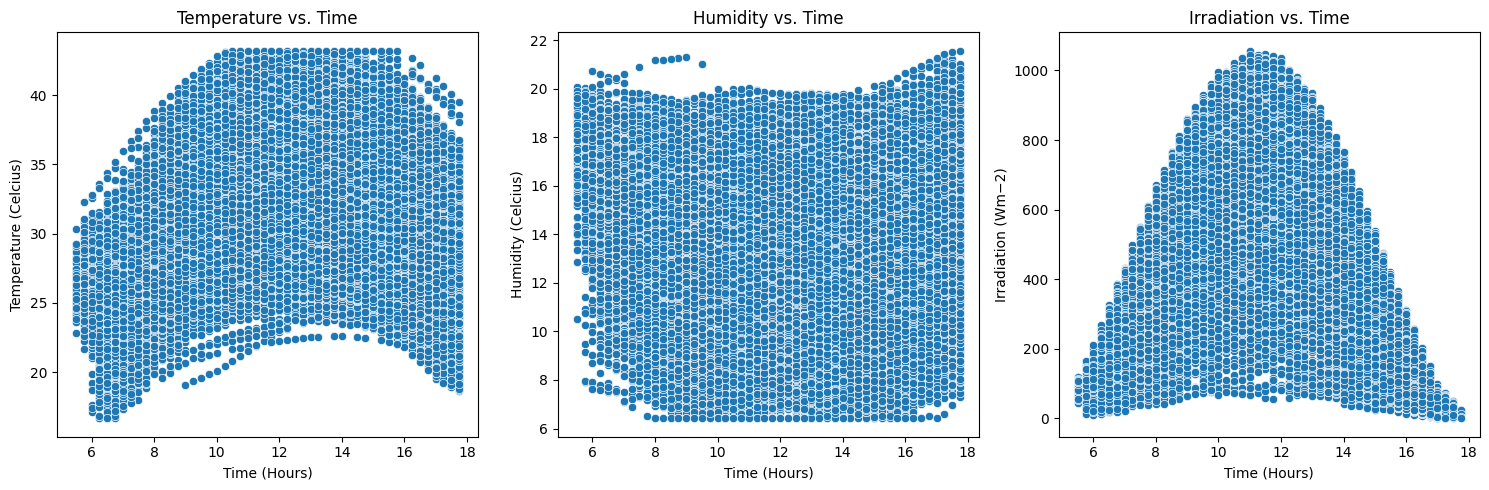

In [36]:
#Plots for Time vs Temperature, Humidity, and Irradiation
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
# Plot 1
sns.scatterplot(data=X_valtrain, x=X_valtrain.TOTAL_MINUTES_PASS/60, y='TEMPERATURE', ax=axes[0])
axes[0].set_title("Temperature vs. Time")

# Plot 2
sns.scatterplot(data=X_valtrain, x=X_valtrain.TOTAL_MINUTES_PASS/60, y='HUMIDITY', ax=axes[1])
axes[1].set_title("Humidity vs. Time")

# Plot 3
sns.scatterplot(data=X_valtrain, x=X_valtrain.TOTAL_MINUTES_PASS/60, y='IRRADIATION', ax=axes[2])
axes[2].set_title("Irradiation vs. Time")


axes[0].set_xlabel("Time (Hours)")
axes[0].set_ylabel("Temperature (Celcius)")

axes[1].set_xlabel("Time (Hours)")
axes[1].set_ylabel("Humidity (Celcius)")

axes[2].set_xlabel("Time (Hours)")
axes[2].set_ylabel("Irradiation (Wm−2)")

plt.tight_layout()
plt.show()

In [37]:
import pandas as pd

# Assuming df_solar is already defined and loaded
# Convert X_train_scaled back to a DataFrame
X_valtrain_df = pd.DataFrame(X_valtrain, columns=['TEMPERATURE', 'HUMIDITY', 'IRRADIATION', 'TOTAL_MINUTES_PASS'])

# Calculate skewness values
skewness_temperature = X_valtrain_df['TEMPERATURE'].skew()
skewness_humidity = X_valtrain_df['HUMIDITY'].skew()
skewness_irradiation = X_valtrain_df['IRRADIATION'].skew()
skewness_total_minutes_pass = X_valtrain_df['TOTAL_MINUTES_PASS'].skew()

print(f"Skewness value for temperature: {skewness_temperature}")
print(f"Skewness value for Humidity: {skewness_humidity}")
print(f"Skewness value for Irradiation: {skewness_irradiation}")
print(f"Skewness value for Total Minutes Pass: {skewness_total_minutes_pass}")

Skewness value for temperature: 0.33686772619657346
Skewness value for Humidity: -0.606734803827727
Skewness value for Irradiation: 0.14235743033505338
Skewness value for Total Minutes Pass: -0.0017775563278932902


In [38]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Scale the training data
X_valtrain_scaled = scaler.fit_transform(X_valtrain)
X_test_scaled = scaler.transform(X_test)


In [39]:
import pandas as pd

# Assuming df_solar is already defined and loaded
# Convert X_train_scaled back to a DataFrame
X_train_scaled_df = pd.DataFrame(X_valtrain, columns=['TEMPERATURE', 'HUMIDITY', 'IRRADIATION', 'TOTAL_MINUTES_PASS'])

# Calculate skewness values
skewness_temperature = X_train_scaled_df['TEMPERATURE'].skew()
skewness_humidity = X_train_scaled_df['HUMIDITY'].skew()
skewness_irradiation = X_train_scaled_df['IRRADIATION'].skew()
skewness_total_minutes_pass = X_train_scaled_df['TOTAL_MINUTES_PASS'].skew()

print(f"Skewness value for temperature: {skewness_temperature}")
print(f"Skewness value for Humidity: {skewness_humidity}")
print(f"Skewness value for Irradiation: {skewness_irradiation}")
print(f"Skewness value for Total Minutes Pass: {skewness_total_minutes_pass}")

Skewness value for temperature: 0.33686772619657346
Skewness value for Humidity: -0.606734803827727
Skewness value for Irradiation: 0.14235743033505338
Skewness value for Total Minutes Pass: -0.0017775563278932902


In [40]:
import pandas as pd

# Assuming y_valtrain is already defined and loaded
skewness_ac_power = y_valtrain.skew()
print(f"Skewness value for AC_POWER: {skewness_ac_power}")

Skewness value for AC_POWER: 0.18758217581234146


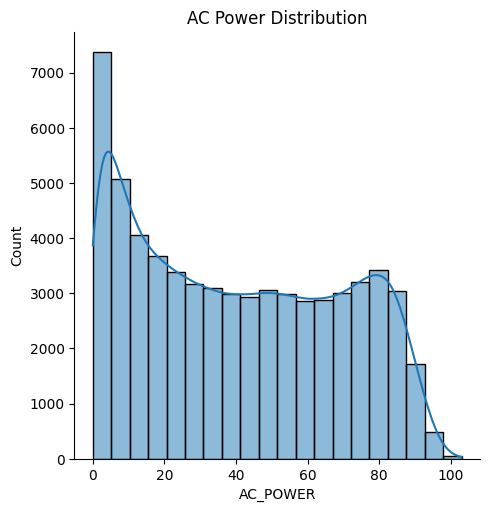

In [41]:
sns.displot(y_valtrain, kde=True, bins = 20).set(title = "AC Power Distribution")
plt.show()

In [42]:
import numpy as np

y_valtrain1=np.log1p(y_valtrain)
y_test1=np.log1p(y_test)

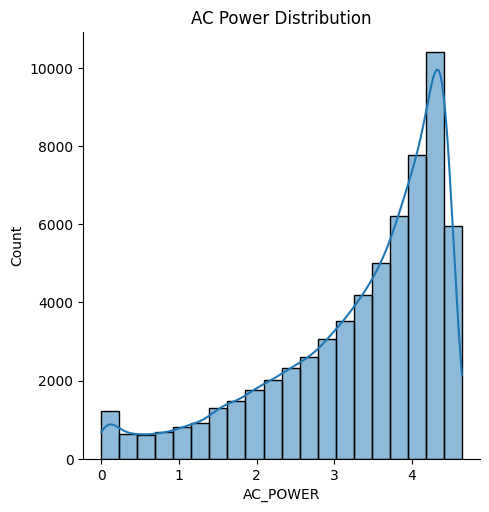

In [43]:
sns.displot(y_valtrain1, kde=True, bins = 20).set(title = "AC Power Distribution")
plt.show()

In [44]:
import pandas as pd

# Assuming y_valtrain1 is already defined and loaded
skewness_ac_power = y_valtrain1.skew()
print(f"Skewness value for AC_POWER: {skewness_ac_power}")

Skewness value for AC_POWER: -1.142383122042318


In [45]:
from sklearn.linear_model import LinearRegression

linear_regressor = LinearRegression() #LR model
linear_regressor.fit(X = X_valtrain,y = y_valtrain1) #Fit training data
y_pred_train = linear_regressor.predict(X_valtrain) # Predictions for training set
y_pred_test = linear_regressor.predict(X_test) #Predictions for test set

# Assuming y_pred_train_rfr2 and y_pred_test_rfr2 are the log-transformed predictions
# Apply the inverse log transformation
y_pred_train_inverse = np.expm1(y_pred_train) - 1
y_pred_test_inverse = np.expm1(y_pred_test) - 1

In [46]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, median_absolute_error

#---Training set metrics---#
lr_r2_train = r2_score(y_valtrain1, y_pred_train) #R-squared for training set
lr_mae_train = mean_absolute_error(y_valtrain, y_pred_train_inverse)
lr_medae_train = median_absolute_error(y_valtrain, y_pred_train_inverse)
lr_rmse_train = np.sqrt(mean_squared_error(y_valtrain, y_pred_train_inverse))

#---Test set metrics---#
lr_r2_test = r2_score(y_test1, y_pred_test) #R-squared for testing set
lr_mae_test = mean_absolute_error(y_test, y_pred_test_inverse)
lr_medae_test = median_absolute_error(y_test, y_pred_test_inverse)
lr_rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test_inverse))

lr_results = pd.DataFrame(
    {'Metric': ['R-squared', 'MAE', 'MedAE', 'RMSE'],
     'Training': [lr_r2_train, lr_mae_train, lr_medae_train, lr_rmse_train],
     'Testing': [lr_r2_test, lr_mae_test, lr_medae_test, lr_rmse_test]}
)

lr_results


,Metric,Training,Testing
0,R-squared,0.745082,0.739654
1,MAE,15.375443,15.458984
2,MedAE,10.198074,10.361918
3,RMSE,22.427568,22.533402


In [47]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(estimator=linear_regressor, X = X_valtrain, y = y_valtrain1, cv=10, scoring='r2') # we use 10 cross validation sets
print(f'Average: {scores.mean():.3f}')
print(f'Standard Deviation: {scores.std():.3f}')

Average: 0.745
Standard Deviation: 0.004


In [48]:
from sklearn.ensemble import RandomForestRegressor
random_forest_regressor = RandomForestRegressor(n_estimators=100, n_jobs=-1,random_state=42) #RFR model with 100 estimators
random_forest_regressor.fit(X = X_valtrain,y = y_valtrain1) # Fit the training set
# y_pred_rfr = random_forest_regressor.predict(X_test) # Predict y for X_test

y_pred_train_rfr = random_forest_regressor.predict(X_valtrain) # Predictions for training set
y_pred_test_rfr = random_forest_regressor.predict(X_test) #Predictions for test set


# Assuming y_pred_train_rfr2 and y_pred_test_rfr2 are the log-transformed predictions
# Apply the inverse log transformation
y_pred_train_rfr_inverse = np.expm1(y_pred_train_rfr) - 1
y_pred_test_rfr_inverse = np.expm1(y_pred_test_rfr) - 1


In [49]:
#---Training set metrics---#
rfr_r2_train = r2_score(y_valtrain1, y_pred_train_rfr) #R-squared for training set
rfr_mae_train = mean_absolute_error(y_valtrain, y_pred_train_rfr_inverse) # Mean Absolute Error for training set
rfr_medae_train = median_absolute_error(y_valtrain, y_pred_train_rfr_inverse) # Median Absolute Error for training set
rfr_rmse_train = np.sqrt(mean_squared_error(y_valtrain, y_pred_train_rfr_inverse)) # Root Mean Squared Error for training set

#---Test set metrics---#
rfr_r2_test = r2_score(y_test1, y_pred_test_rfr) #R-squared for test set
rfr_mae_test = mean_absolute_error(y_test, y_pred_test_rfr_inverse) # Mean Absolute Error for test set
rfr_medae_test = median_absolute_error(y_test, y_pred_test_rfr_inverse) # Median Absolute Error for test set
rfr_rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test_rfr_inverse)) # Root Mean Squared Error for test set

rfr_results = pd.DataFrame(
    {'Metric': ['R-squared', 'MAE', 'MedAE', 'RMSE'],
     'Training': [rfr_r2_train, rfr_mae_train, rfr_medae_train, rfr_rmse_train],
     'Testing': [rfr_r2_test, rfr_mae_test, rfr_medae_test, rfr_rmse_test]}
)

rfr_results


,Metric,Training,Testing
0,R-squared,0.986956,0.907065
1,MAE,3.029159,7.234623
2,MedAE,1.892249,4.372024
3,RMSE,4.440897,10.837895


In [50]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rfr_reg = RandomForestRegressor(random_state=42)

# Define a medium-sized parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100,200, 500],  # Moderate number of trees
    'max_depth': [20, 30, None],  # Depth for controlling complexity
    'min_samples_split': [2, 5,8],  # Minimum samples for splitting nodes
    'min_samples_leaf': [1, 2,5],  # Minimum samples in leaf nodes
    'bootstrap': [True],  # Use bootstrapping for robust trees
    'max_features': ['auto', 'sqrt']  # Number of features to consider for split
}

# Perform Grid Search with cross-validation
grid_search = GridSearchCV(estimator=rfr_reg, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2, scoring='r2')

grid_search.fit(X_valtrain, y_valtrain1)

random_forest_regressor_2 = grid_search.best_estimator_
print(random_forest_regressor_2)


Fitting 3 folds for each of 162 candidates, totalling 486 fits


c:\Users\netha\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
243 fits failed out of a total of 486.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
144 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\netha\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\netha\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "c:\Users\netha\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py"

RandomForestRegressor(max_depth=20, max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=5, n_estimators=500, random_state=42)


In [ ]:
random_forest_regressor_2.fit(X_valtrain,y_valtrain1) # Fit the training set

y_pred_train_rfr2 = random_forest_regressor_2.predict(X_valtrain) # Predictions for training set
y_pred_test_rfr2 = random_forest_regressor_2.predict(X_test) #Predictions for test set


# Assuming y_pred_train_rfr2 and y_pred_test_rfr2 are the log-transformed predictions
# Apply the inverse log transformation
y_pred_train_rfr2_inverse = np.expm1(y_pred_train_rfr2) - 1
y_pred_test_rfr2_inverse = np.expm1(y_pred_test_rfr2) - 1


In [ ]:

#---Training set metrics---#
rfr_r2_train_2 = r2_score(y_valtrain1, y_pred_train_rfr2) # R-squared for training set
rfr_mae_train_2 = mean_absolute_error(y_valtrain, y_pred_train_rfr2_inverse) # Mean Absolute Error for training set
rfr_medae_train_2 = median_absolute_error(y_valtrain, y_pred_train_rfr2_inverse) # Median Absolute Error for training set
rfr_rmse_train_2 = np.sqrt(mean_squared_error(y_valtrain, y_pred_train_rfr2_inverse)) # Root Mean Squared Error for training set

#---Test set metrics---#
rfr_r2_test_2 = r2_score(y_test1, y_pred_test_rfr2) # R-squared for test set
rfr_mae_test_2 = mean_absolute_error(y_test, y_pred_test_rfr2_inverse) # Mean Absolute Error for test set
rfr_medae_test_2 = median_absolute_error(y_test, y_pred_test_rfr2_inverse) # Median Absolute Error for test set
rfr_rmse_test_2 = np.sqrt(mean_squared_error(y_test, y_pred_test_rfr2_inverse)) # Root Mean Squared Error for test set

# Create a DataFrame to hold the results
rfr_results_2 = pd.DataFrame(
    {'Metric': ['R-squared', 'MAE', 'MedAE', 'RMSE'],
     'Training': [rfr_r2_train_2, rfr_mae_train_2, rfr_medae_train_2, rfr_rmse_train_2],
     'Testing': [rfr_r2_test_2, rfr_mae_test_2, rfr_medae_test_2, rfr_rmse_test_2]}
)

rfr_results_2

,Metric,Training,Testing
0,R-squared,0.965694,0.910089
1,MAE,4.639555,7.112506
2,MedAE,2.785419,4.330125
3,RMSE,6.898829,10.608426


In [ ]:
import xgboost as xgb
from xgboost import XGBRegressor

# Set optimized hyperparameters for XGBoost
best_xgb_reg = XGBRegressor(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42)

# Train the model
best_xgb_reg.fit(X_valtrain, y_valtrain1)

# Make predictions on the training set
y_pred_train_xgb = best_xgb_reg.predict(X_valtrain)

# Make predictions on the test set
y_pred_test_xgb = best_xgb_reg.predict(X_test)


# Assuming y_pred_train_rfr2 and y_pred_test_rfr2 are the log-transformed predictions
# Apply the inverse log transformation
y_pred_train_xgb_inverse = np.expm1(y_pred_train_xgb) - 1
y_pred_test_xgb_inverse = np.expm1(y_pred_test_xgb) - 1


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, median_absolute_error


#---Training set metrics---#
xgb_r2_train = r2_score(y_valtrain1, y_pred_train_xgb) # R-squared for training set
xgb_mae_train = mean_absolute_error(y_valtrain, y_pred_train_xgb_inverse) # Mean Absolute Error for training set
xgb_medae_train = median_absolute_error(y_valtrain, y_pred_train_xgb_inverse) # Median Absolute Error for training set
xgb_rmse_train = np.sqrt(mean_squared_error(y_valtrain, y_pred_train_xgb_inverse)) # Root Mean Squared Error for training set

#---Test set metrics---#
xgb_r2_test = r2_score(y_test1, y_pred_test_xgb) # R-squared for test set
xgb_mae_test = mean_absolute_error(y_test, y_pred_test_xgb_inverse) # Mean Absolute Error for test set
xgb_medae_test = median_absolute_error(y_test, y_pred_test_xgb_inverse) # Median Absolute Error for test set
xgb_rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test_xgb_inverse)) # Root Mean Squared Error for test set

# Create a DataFrame to hold the results
xgb_results = pd.DataFrame(
    {'Metric': ['R-squared', 'MAE', 'MedAE', 'RMSE'],
     'Training': [xgb_r2_train, xgb_mae_train, xgb_medae_train, xgb_rmse_train],
     'Testing': [xgb_r2_test, xgb_mae_test, xgb_medae_test, xgb_rmse_test]}
)

xgb_results

,Metric,Training,Testing
0,R-squared,0.896336,0.891879
1,MAE,8.111922,8.169070
2,MedAE,5.648451,5.644386
3,RMSE,11.459191,11.587182


Deep Neural Network (DNN)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Build DNN Model
model = Sequential()
model.add(Dense(64, input_dim=X_valtrain.shape[1], activation='relu'))  # Input layer
model.add(Dense(128, activation='relu'))  # Hidden layer 1
model.add(Dense(64, activation='relu'))  # Hidden layer 2
model.add(Dense(1))  # Output layer for regression

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])


# Train the model
history = model.fit(X_valtrain, y_valtrain1, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# Predict and calculate R-squared for train and test sets
y_pred_train_dnn = model.predict(X_valtrain)
y_pred_test_dnn = model.predict(X_test)


# Assuming y_pred_train_rfr2 and y_pred_test_rfr2 are the log-transformed predictions
# Apply the inverse log transformation
y_pred_train_dnn_inverse = np.expm1(y_pred_train_dnn) - 1
y_pred_test_dnn_inverse = np.expm1(y_pred_test_dnn) - 1


c:\Users\netha\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1953/1953 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 17.2126 - mean_absolute_error: 1.4762 - val_loss: 2118.8931 - val_mean_absolute_error: 37.1070
Epoch 2/50
1953/1953 ━━━━━━━━━━━━━━━━━━━━ 85s 44ms/step - loss: 1.4889 - mean_absolute_error: 0.8824 - val_loss: 2129.2000 - val_mean_absolute_error: 37.3725
Epoch 3/50
1953/1953 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.8106 - mean_absolute_error: 0.6710 - val_loss: 2162.6267 - val_mean_absolute_error: 37.7294
Epoch 4/50
1953/1953 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.5284 - mean_absolute_error: 0.5403 - val_loss: 2175.6655 - val_mean_absolute_error: 37.8027
Epoch 5/50
1953/1953 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3419 - mean_absolute_error: 0.4494 - val_loss: 2114.1213 - val_mean_absolute_error: 37.1481
Epoch 6/50
1953/1953 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2772 - mean_absolute_error: 0.4023 - val_loss: 2145.6575 - val_mean_absolute_error: 37.4939
Epoch 7/50
1953/1953 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss:

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, median_absolute_error

#---Training set metrics---#
dnn_r2_train = r2_score(y_valtrain1, y_pred_train_dnn) # R-squared for training set
dnn_mae_train = mean_absolute_error(y_valtrain, y_pred_train_dnn_inverse) # Mean Absolute Error for training set
dnn_medae_train = median_absolute_error(y_valtrain, y_pred_train_dnn_inverse) # Median Absolute Error for training set
dnn_rmse_train = np.sqrt(mean_squared_error(y_valtrain, y_pred_train_dnn_inverse)) # Root Mean Squared Error for training set

#---Test set metrics---#
dnn_r2_test = r2_score(y_test1, y_pred_test_dnn) # R-squared for test set
dnn_mae_test = mean_absolute_error(y_test, y_pred_test_dnn_inverse) # Mean Absolute Error for test set
dnn_medae_test = median_absolute_error(y_test, y_pred_test_dnn_inverse) # Median Absolute Error for test set
dnn_rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test_dnn_inverse)) # Root Mean Squared Error for test set

# Create a DataFrame to hold the results
dnn_results = pd.DataFrame(
    {'Metric': ['R-squared', 'MAE', 'MedAE', 'RMSE'],
     'Training': [dnn_r2_train, dnn_mae_train, dnn_medae_train, dnn_rmse_train],
     'Testing': [dnn_r2_test, dnn_mae_test, dnn_medae_test, dnn_rmse_test]}
)

dnn_results

,Metric,Training,Testing
0,R-squared,0.894773,0.892020
1,MAE,7.864207,7.896911
2,MedAE,5.184668,5.240643
3,RMSE,11.323525,11.419165


In [ ]:
# Convert time to total minutes
temperature=26.885
humidity=16.735
irradiation=504.815
time_of_day = "9:30"

hours, minutes = map(int, time_of_day.split(':'))  # Split into hours and minutes
total_minutes = hours * 60 + minutes  # Calculate total minutes

input_data = np.array([[temperature, humidity, irradiation, total_minutes]])
print(input_data)

prediction = model.predict(input_data)

prediction1 = np.expm1(prediction) - 1\

print(prediction1)

[[ 26.885  16.735 504.815 570.   ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
[[3.6232786]]


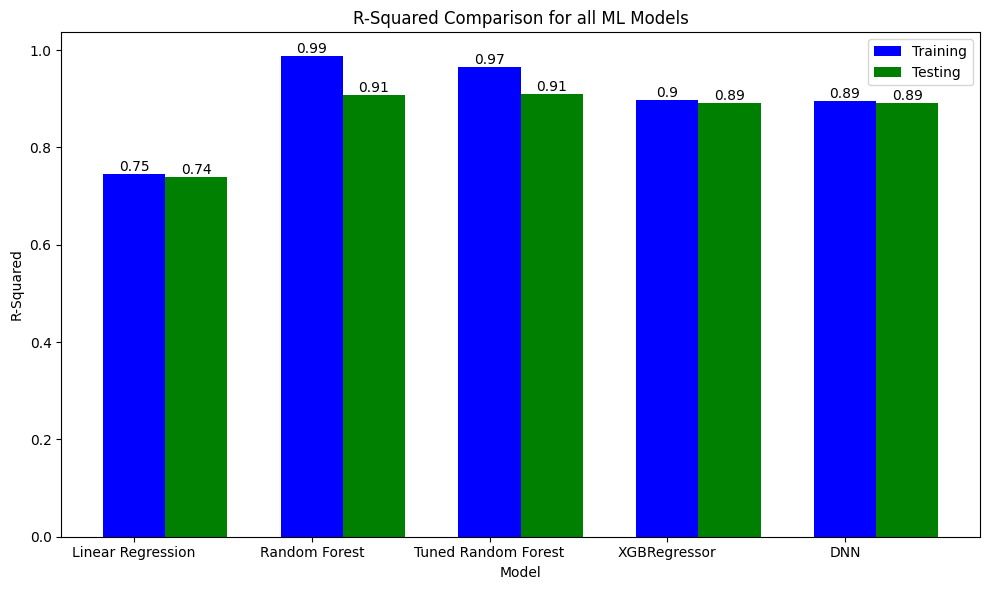

In [ ]:
import matplotlib.pyplot as plt

# Comparison of R-Squared values of each models
models = ['Linear Regression', 'Random Forest', 'Tuned Random Forest', 'XGBRegressor', 'DNN']
r2_train = [lr_results.loc[0, 'Training'], rfr_results.loc[0, 'Training'], rfr_results_2.loc[0, 'Training'], xgb_results.loc[0, 'Training'], dnn_results.loc[0, 'Training']]
r2_test = [lr_results.loc[0, 'Testing'], rfr_results.loc[0, 'Testing'], rfr_results_2.loc[0, 'Testing'], xgb_results.loc[0, 'Testing'], dnn_results.loc[0, 'Testing']]
bar_width = 0.35
train_pos = [i for i, _ in enumerate(models)]
test_pos = [x + bar_width for x in train_pos]

plt.figure(figsize=(10, 6))
bars_train = plt.bar(train_pos, r2_train, color='blue', width=bar_width, label='Training')
bars_test = plt.bar(test_pos, r2_test, color='green', width=bar_width, label='Testing')

# Annotate bars with values
for bar in bars_train:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, round(yval, 2), ha='center', va='bottom')

for bar in bars_test:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, round(yval, 2), ha='center', va='bottom')

plt.xlabel('Model')
plt.ylabel('R-Squared')
plt.title('R-Squared Comparison for all ML Models')
plt.xticks(train_pos, models)
plt.legend()
plt.tight_layout()
plt.show()

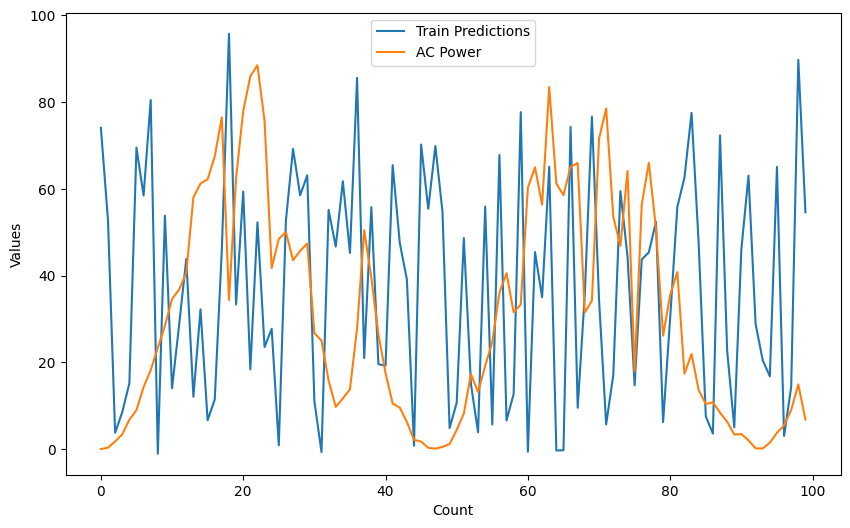

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensure y_pred_train and AC_POWER have the same length
min_length = 100
y_pred_train_adjusted = np.array(y_pred_train_dnn_inverse[:min_length]).flatten()
ac_power_adjusted = np.array(df_solar['AC_POWER'].iloc[:min_length]).flatten()

# Create a DataFrame to hold both series
comparison_df = pd.DataFrame({
    'Count': np.arange(min_length),
    'Train Predictions': y_pred_train_adjusted,
    'AC Power': ac_power_adjusted
})

# Plot using seaborn.lineplot
plt.figure(figsize=(10, 6))
sns.lineplot(x='Count', y='Train Predictions', data=comparison_df, label='Train Predictions')
sns.lineplot(x='Count', y='AC Power', data=comparison_df, label='AC Power')
plt.xlabel('Count')
plt.ylabel('Values')
plt.legend()
plt.show()

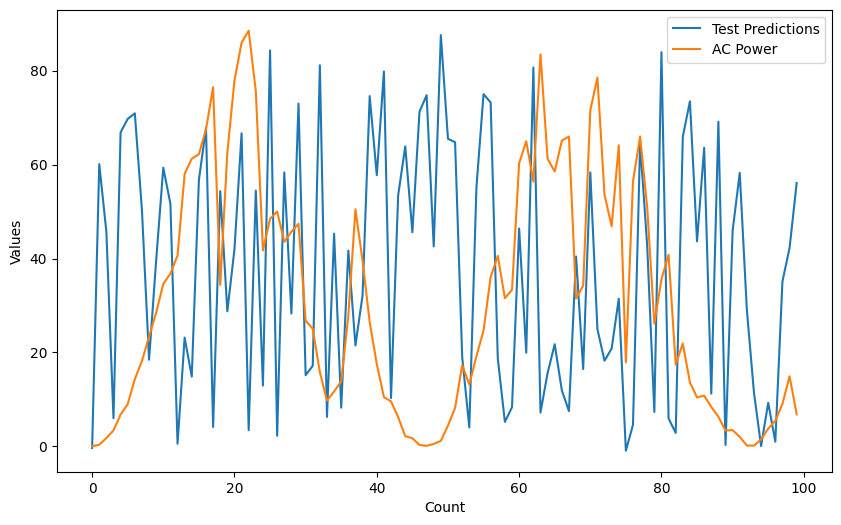

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensure y_pred_train and AC_POWER have the same length
min_length = 100
y_pred_test_adjusted = np.array(y_pred_test_rfr2_inverse[:min_length]).flatten()
ac_power_adjusted = np.array(df_solar['AC_POWER'].iloc[:min_length]).flatten()

# Create a DataFrame to hold both series
comparison_df = pd.DataFrame({
    'Count': np.arange(min_length),
    'Test Predictions': y_pred_test_adjusted,
    'AC Power': ac_power_adjusted
})

# Plot using seaborn.lineplot
plt.figure(figsize=(10, 6))
sns.lineplot(x='Count', y='Test Predictions', data=comparison_df, label='Test Predictions')
sns.lineplot(x='Count', y='AC Power', data=comparison_df, label='AC Power')
plt.xlabel('Count')
plt.ylabel('Values')
plt.legend()
plt.show()

In [ ]:
import pickle

# Step 1: Train your model (assuming `model` is the trained model object)
# Example: model = SomeMLModel().fit(X_train, y_train)

# Save the model to a file
with open('SolarPowerGenerationPrediction.ipynb', 'wb') as file:
    pickle.dump(model, file)
print("Model saved successfully!")

# Step 2: Load the model for later use
# Assuming 'model' is your trained model
model_path = 'loaded_model.pkl'
with open(model_path, 'wb') as file:
    pickle.dump(model, file)
    

Model saved successfully!
